In [15]:
import os

train_dir = "../Data/brain_tumor/Training"
test_dir = "../Data/brain_tumor/Testing"

print("Training classes:")
print(os.listdir(train_dir))

print("\nTesting classes:")
print(os.listdir(test_dir))

Training classes:
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

Testing classes:
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [18]:
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    print(class_name, len(os.listdir(class_path)))

for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    print(class_name, len(os.listdir(class_path)))

glioma_tumor 826
meningioma_tumor 822
no_tumor 395
pituitary_tumor 827
glioma_tumor 100
meningioma_tumor 115
no_tumor 105
pituitary_tumor 74


In [19]:
from PIL import Image
import os

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    first_image = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, first_image)

    image = Image.open(image_path)

    print(class_name)
    print("File:", first_image)
    print("Size:", image.size)
    print("Mode:", image.mode)
    print()

glioma_tumor
File: gg (1).jpg
Size: (512, 512)
Mode: RGB

meningioma_tumor
File: m (10).jpg
Size: (512, 512)
Mode: RGB

no_tumor
File: 1.jpg
Size: (350, 350)
Mode: RGB

pituitary_tumor
File: p (1).jpg
Size: (512, 512)
Mode: RGB



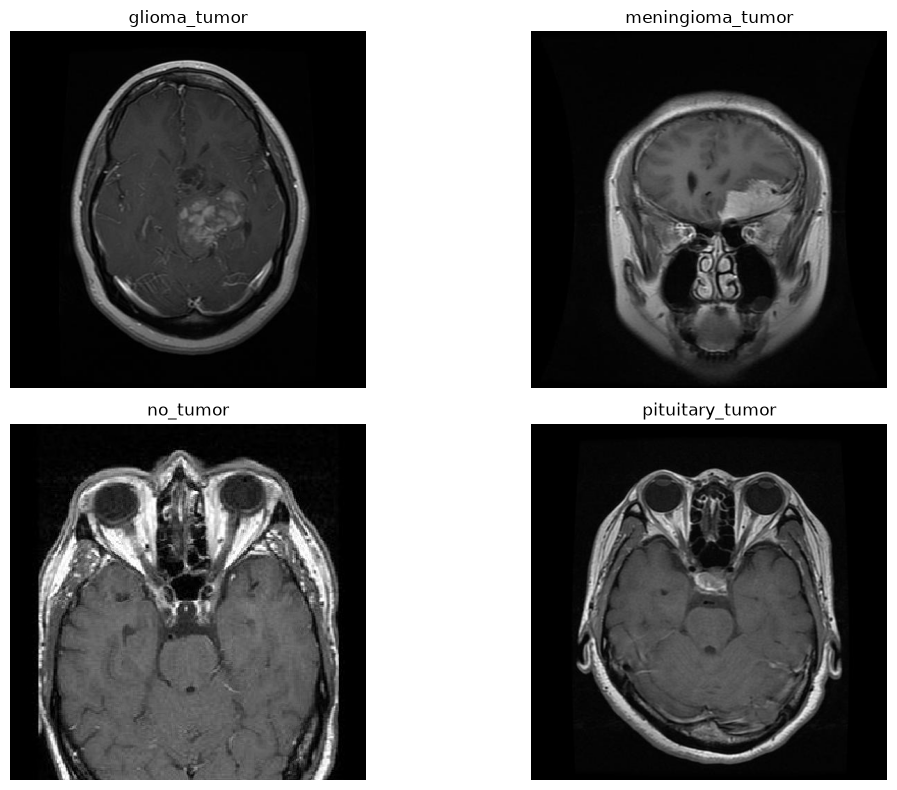

In [20]:
import matplotlib.pyplot as plt
from PIL import Image
import os

classes = os.listdir(train_dir)

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)

    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

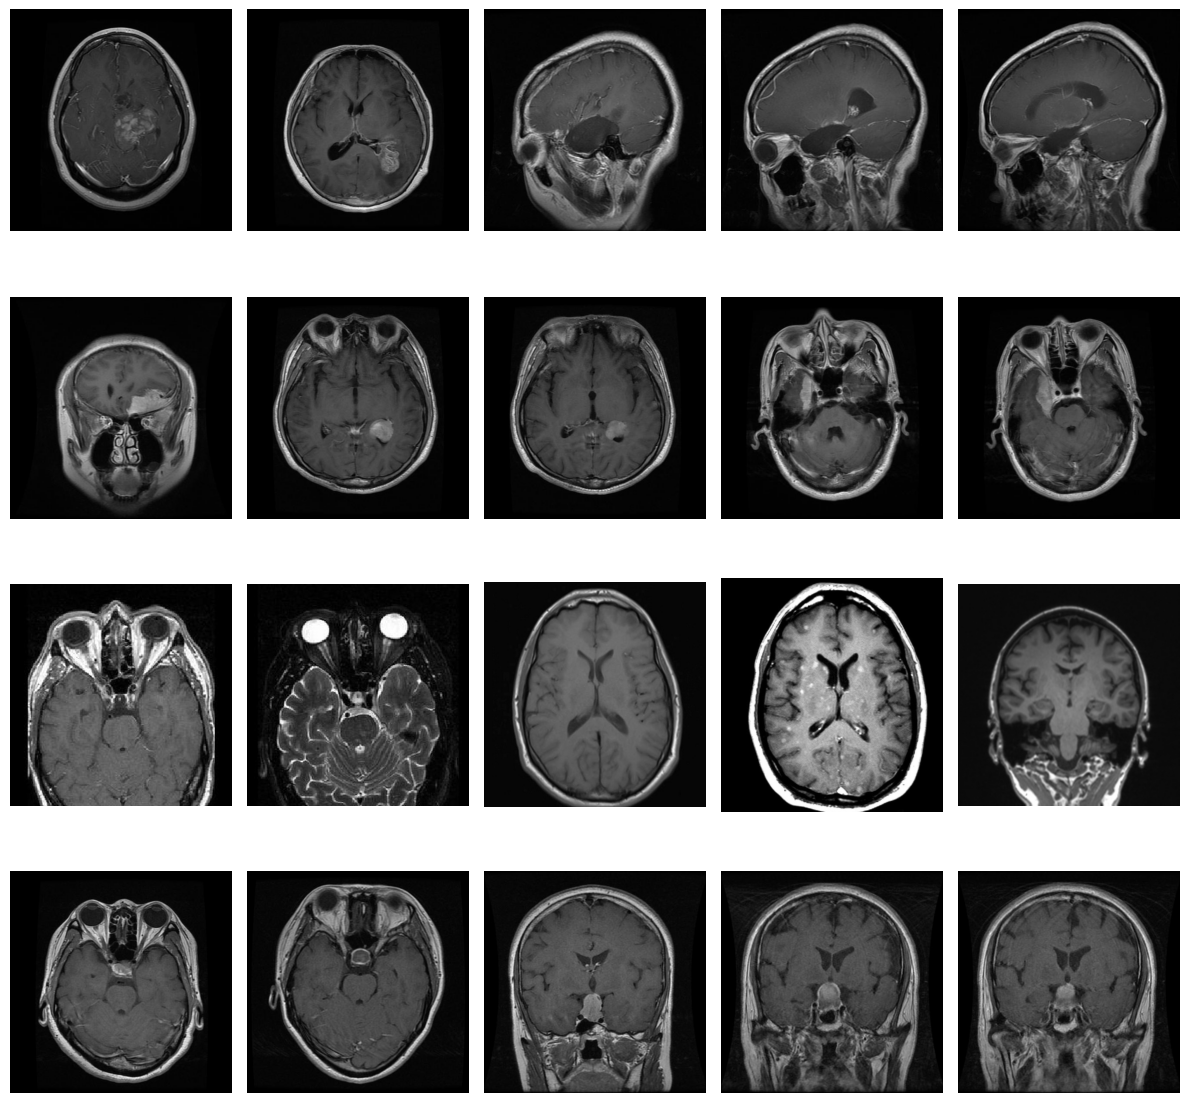

In [21]:
import matplotlib.pyplot as plt
from PIL import Image
import os

classes = os.listdir(train_dir)

plt.figure(figsize=(12, 12))

for row, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    image_names = os.listdir(class_path)[:5]

    for col, image_name in enumerate(image_names):
        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path)

        position = row * 5 + col + 1

        plt.subplot(4, 5, position)
        plt.imshow(image)
        plt.axis("off")

        if col == 0:
            plt.ylabel(class_name)

plt.tight_layout()
plt.show()

In [22]:
from collections import Counter
import os
import matplotlib.pyplot as plt

train_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    train_counts[class_name] = len(os.listdir(class_path))

print(train_counts)

{'glioma_tumor': 826, 'meningioma_tumor': 822, 'no_tumor': 395, 'pituitary_tumor': 827}


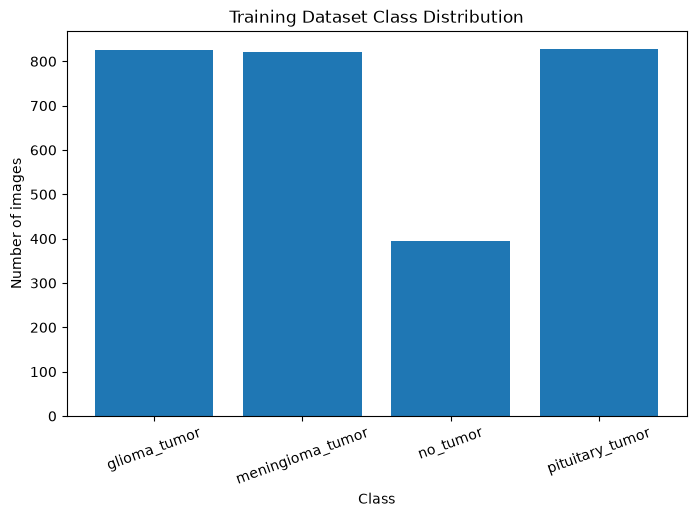

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(train_counts.keys(), train_counts.values())

plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Training Dataset Class Distribution")

plt.xticks(rotation=20)
plt.show()

Basically we are creating finger print for each image 
MRI IMAGE -> MD5 Hash -> Unique Fingerprint


In [24]:
import os
import hashlib

def get_image_hash(image_path):
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


train_hashes = {}
test_hashes = {}

# Training images
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image_hash = get_image_hash(image_path)

        train_hashes[image_hash] = (class_name, image_name)


# Testing images
for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image_hash = get_image_hash(image_path)

        test_hashes[image_hash] = (class_name, image_name)


duplicates = set(train_hashes.keys()) & set(test_hashes.keys())

print("Exact duplicates between Training and Testing:", len(duplicates))

Exact duplicates between Training and Testing: 64


In [25]:
print("Number of duplicate images:", len(duplicates))

print("\nSome duplicate examples:")

for image_hash in list(duplicates)[:10]:
    print("Training:", train_hashes[image_hash])
    print("Testing :", test_hashes[image_hash])
    print()

Number of duplicate images: 64

Some duplicate examples:
Training: ('no_tumor', 'image(71).jpg')
Testing : ('no_tumor', 'image(96).jpg')

Training: ('no_tumor', 'image(65).jpg')
Testing : ('no_tumor', 'image(90).jpg')

Training: ('no_tumor', 'image(272).jpg')
Testing : ('no_tumor', 'image(104).jpg')

Training: ('no_tumor', 'image(6).jpg')
Testing : ('no_tumor', 'image(30).jpg')

Training: ('no_tumor', 'image(2).jpg')
Testing : ('no_tumor', 'image(26).jpg')

Training: ('no_tumor', 'image.jpg')
Testing : ('no_tumor', 'image(70).jpg')

Training: ('no_tumor', 'image(60).jpg')
Testing : ('no_tumor', 'image(85).jpg')

Training: ('no_tumor', 'image(18).jpg')
Testing : ('no_tumor', 'image(43).jpg')

Training: ('no_tumor', 'image(57).jpg')
Testing : ('no_tumor', 'image(82).jpg')

Training: ('no_tumor', 'image(268).jpg')
Testing : ('no_tumor', 'image(102).jpg')



In [26]:
from collections import Counter

duplicate_classes = []

for image_hash in duplicates:
    train_class = train_hashes[image_hash][0]
    test_class = test_hashes[image_hash][0]

    duplicate_classes.append((train_class, test_class))

print(Counter(duplicate_classes))

Counter({('no_tumor', 'no_tumor'): 64})


In [27]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [28]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\mmsre\anaconda3\envs\brainmri\python.exe
3.11.16 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:36:16) [MSC v.1942 64 bit (AMD64)]


In [29]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [30]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transform
)

In [31]:
print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)
print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Class mapping: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Training images: 2870
Testing images: 394


In [35]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [34]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [36]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: tensor([3, 3, 1, 0, 3, 0, 0, 3, 3, 3])


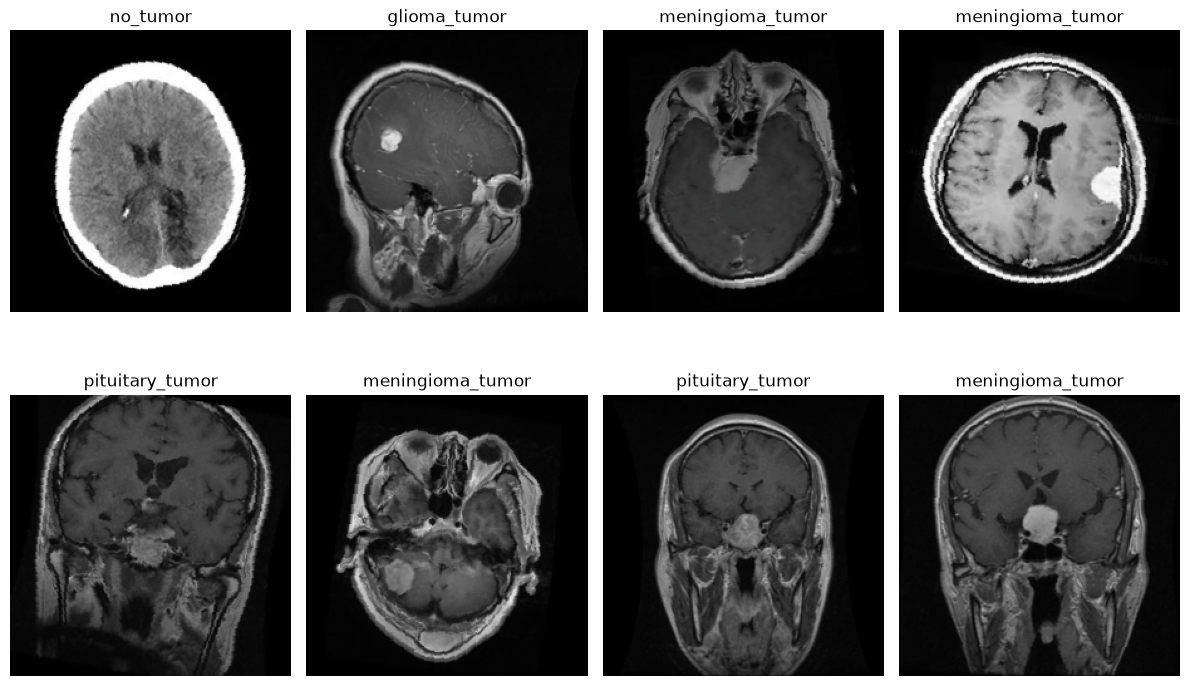

In [37]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    # Undo normalization for visualization
    image = images[i].permute(1, 2, 0)
    image = image * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])

    image = torch.clamp(image, 0, 1)

    plt.imshow(image)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print(model)

Using device: cpu
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True,

In [22]:
num_classes = len(train_dataset.classes)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

In [23]:
print(model.fc)

Linear(in_features=512, out_features=4, bias=True)


In [24]:
import torch
import torch.nn as nn

class_counts = [826, 822, 395, 827]

total = sum(class_counts)

class_weights = [
    total / (len(class_counts) * count)
    for count in class_counts
]

print("Class weights:", class_weights)
#no_tumor receives a higher penalty when the model misclassifies it.

Class weights: [0.8686440677966102, 0.8728710462287105, 1.8164556962025316, 0.8675937122128174]


Convert them to a PyTorch tensor

In [25]:
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print(class_weights)

tensor([0.8686, 0.8729, 1.8165, 0.8676])


Create the loss function

In [26]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print(criterion)

CrossEntropyLoss()


Adam is used as optimizer for transfer learning

In [27]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [28]:
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


Validation Split

In [29]:
from sklearn.model_selection import train_test_split

indices = list(range(len(train_dataset)))
labels = train_dataset.targets

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

Training samples: 2296
Validation samples: 574


In [30]:
from torch.utils.data import Subset

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

print("Training subset:", len(train_subset))
print("Validation subset:", len(val_subset))

Training subset: 2296
Validation subset: 574


In [31]:
train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 72
Validation batches: 18


In [32]:
val_dataset_full = datasets.ImageFolder(
    train_dir,
    transform=test_transform
)

In [33]:
val_dataset = Subset(
    val_dataset_full,
    val_indices
)

print("Validation samples:", len(val_dataset))

Validation samples: 574


In [34]:
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Validation batches:", len(val_loader))

Validation batches: 18


In [35]:
images, labels = next(iter(val_loader))

print("Validation image shape:", images.shape)
print("Validation label shape:", labels.shape)

Validation image shape: torch.Size([32, 3, 224, 224])
Validation label shape: torch.Size([32])


In [36]:
model.train()

running_loss = 0.0
correct = 0
total = 0

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    # Clear previous gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(images)

    # Calculate loss
    loss = criterion(outputs, labels)

    # Backpropagation
    loss.backward()

    # Update model weights
    optimizer.step()

    # Track loss
    running_loss += loss.item()

    # Track accuracy
    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

epoch_loss = running_loss / len(train_loader)
epoch_accuracy = 100 * correct / total

print("Training Loss:", epoch_loss)
print("Training Accuracy:", epoch_accuracy)

KeyboardInterrupt: 

In [ ]:
model.eval()

val_running_loss = 0.0
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate validation loss
        loss = criterion(outputs, labels)

        val_running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Track accuracy
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

val_loss = val_running_loss / len(val_loader)
val_accuracy = 100 * val_correct / val_total

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

Validation Loss: 0.26456398392717045
Validation Accuracy: 88.32752613240419


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = train_running_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # -------------------------
    # Results
    # -------------------------
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/5] Train Loss: 0.1386 Train Acc: 94.77% Val Loss: 0.2334 Val Acc: 90.24%
Epoch [2/5] Train Loss: 0.0802 Train Acc: 97.30% Val Loss: 0.1447 Val Acc: 93.90%
Epoch [3/5] Train Loss: 0.0596 Train Acc: 97.69% Val Loss: 0.0947 Val Acc: 96.17%
Epoch [4/5] Train Loss: 0.0515 Train Acc: 98.39% Val Loss: 0.1378 Val Acc: 94.43%
Epoch [5/5] Train Loss: 0.0299 Train Acc: 99.22% Val Loss: 0.0991 Val Acc: 95.64%


In [ ]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]

train_losses = [0.1386, 0.0802, 0.0596, 0.0515, 0.0299]
val_losses = [0.2334, 0.1447, 0.0947, 0.1378, 0.0991]

train_accuracies = [94.77, 97.30, 97.69, 98.39, 99.22]
val_accuracies = [90.24, 93.90, 96.17, 94.43, 95.64]

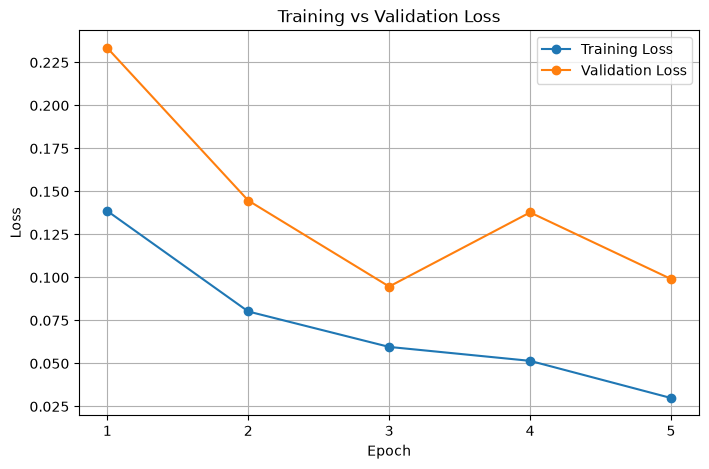

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()

We are going to save best model

In [ ]:
num_epochs = 5

best_val_accuracy = 0.0

for epoch in range(num_epochs):

    # =========================
    # Training
    # =========================
    model.train()

    train_running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = train_running_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    # =========================
    # Validation
    # =========================
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # =========================
    # Save best model
    # =========================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "best_brain_mri_resnet18.pth"
        )

        print(">>> Best model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

print("Best Validation Accuracy:", best_val_accuracy)

>>> Best model saved!
Epoch [1/5] Train Loss: 0.0245 Train Acc: 99.35% Val Loss: 0.0945 Val Acc: 96.69%
>>> Best model saved!
Epoch [2/5] Train Loss: 0.0181 Train Acc: 99.61% Val Loss: 0.0667 Val Acc: 97.39%
Epoch [3/5] Train Loss: 0.0206 Train Acc: 99.35% Val Loss: 0.0845 Val Acc: 95.99%
Epoch [4/5] Train Loss: 0.0136 Train Acc: 99.56% Val Loss: 0.1098 Val Acc: 96.69%
Epoch [5/5] Train Loss: 0.0132 Train Acc: 99.61% Val Loss: 0.0933 Val Acc: 96.69%
Best Validation Accuracy: 97.38675958188153


In [ ]:
import os

print(os.path.exists("best_brain_mri_resnet18.pth"))

True


In [1]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)

num_classes = 4

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

print("Model recreated successfully.")
print("Using device:", device)

Model recreated successfully.
Using device: cpu


In [2]:
model.load_state_dict(
    torch.load(
        "best_brain_mri_resnet18.pth",
        map_location=device
    )
    
)

model = model.to(device)

print("Best model loaded successfully.")

Best model loaded successfully.


In [3]:
print("test_loader" in globals())

False


Recreate test_loader

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dir = "../Data/brain_tumor/Testing"

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Test samples:", len(test_dataset))
print("Classes:", test_dataset.classes)

Test samples: 394
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [5]:
print("test_loader" in globals())

True


Test Accuracy

In [6]:
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_accuracy = 100 * test_correct / test_total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 73.85786802030456


Classification Matrix

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes
))

                  precision    recall  f1-score   support

    glioma_tumor       0.88      0.22      0.35       100
meningioma_tumor       0.66      1.00      0.80       115
        no_tumor       0.72      0.95      0.82       105
 pituitary_tumor       0.95      0.73      0.82        74

        accuracy                           0.74       394
       macro avg       0.80      0.73      0.70       394
    weighted avg       0.79      0.74      0.70       394



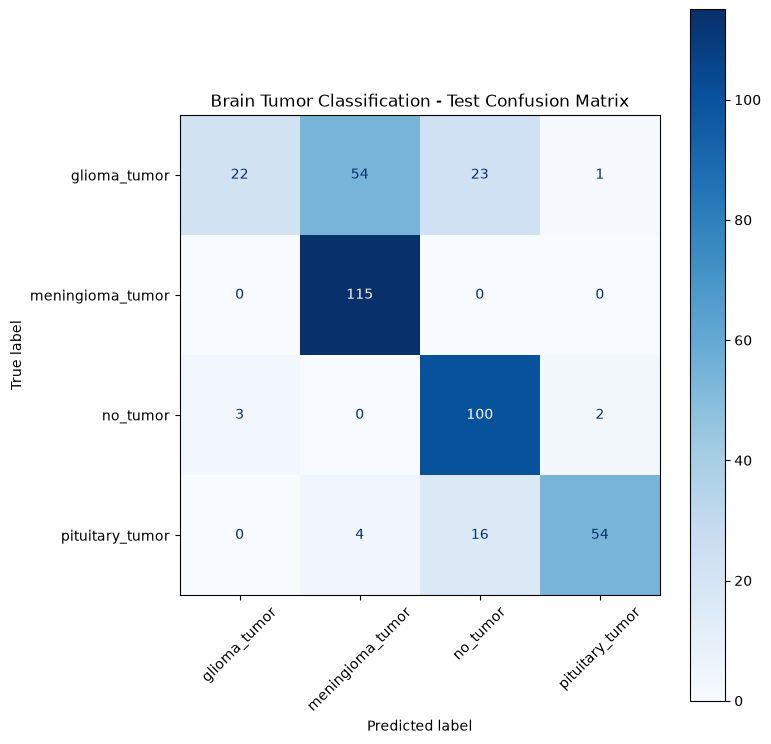

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Brain Tumor Classification - Test Confusion Matrix")
plt.tight_layout()
plt.show()

Find incorrectly classified MRI images

In [9]:
import matplotlib.pyplot as plt

model.eval()

wrong_images = []
wrong_labels = []
wrong_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):

            if predicted[i].cpu() != labels[i]:

                wrong_images.append(images[i].cpu())
                wrong_labels.append(labels[i].item())
                wrong_predictions.append(predicted[i].cpu().item())

print("Number of incorrect predictions:", len(wrong_images))

Number of incorrect predictions: 103


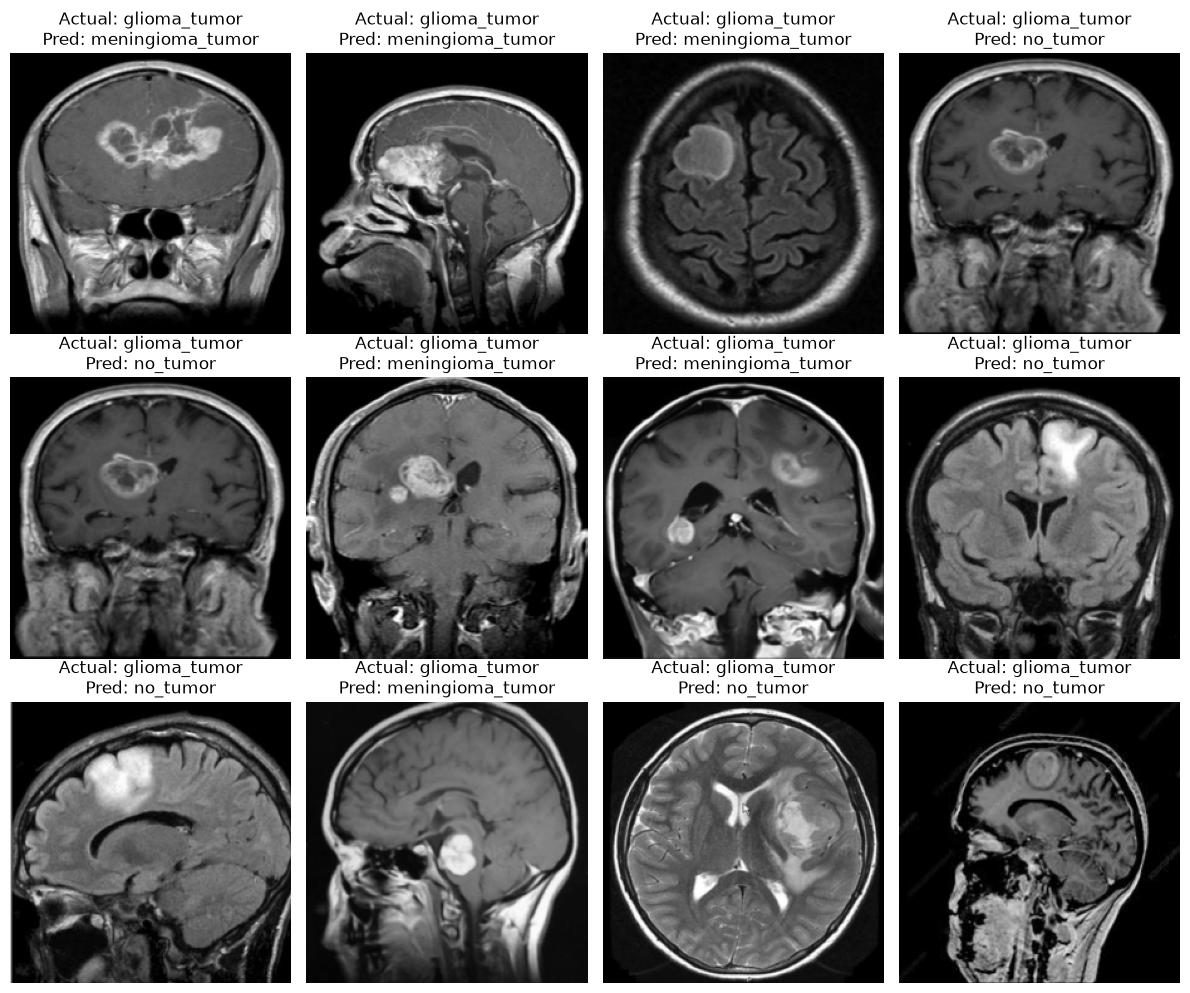

In [10]:
#Visua;ize 12 images
plt.figure(figsize=(12, 10))

for i in range(min(12, len(wrong_images))):

    image = wrong_images[i].permute(1, 2, 0)

    # Undo normalization
    image = image * torch.tensor([0.229, 0.224, 0.225])
    image = image + torch.tensor([0.485, 0.456, 0.406])

    image = torch.clamp(image, 0, 1)

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    actual = test_dataset.classes[wrong_labels[i]]
    predicted = test_dataset.classes[wrong_predictions[i]]

    plt.title(
        f"Actual: {actual}\nPred: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
from collections import Counter

error_pairs = Counter(
    (
        test_dataset.classes[actual],
        test_dataset.classes[pred]
    )
    for actual, pred in zip(wrong_labels, wrong_predictions)
)

for (actual, predicted), count in error_pairs.most_common():
    print(f"{actual} -> {predicted}: {count}")

glioma_tumor -> meningioma_tumor: 54
glioma_tumor -> no_tumor: 23
pituitary_tumor -> no_tumor: 16
pituitary_tumor -> meningioma_tumor: 4
no_tumor -> glioma_tumor: 3
no_tumor -> pituitary_tumor: 2
glioma_tumor -> pituitary_tumor: 1


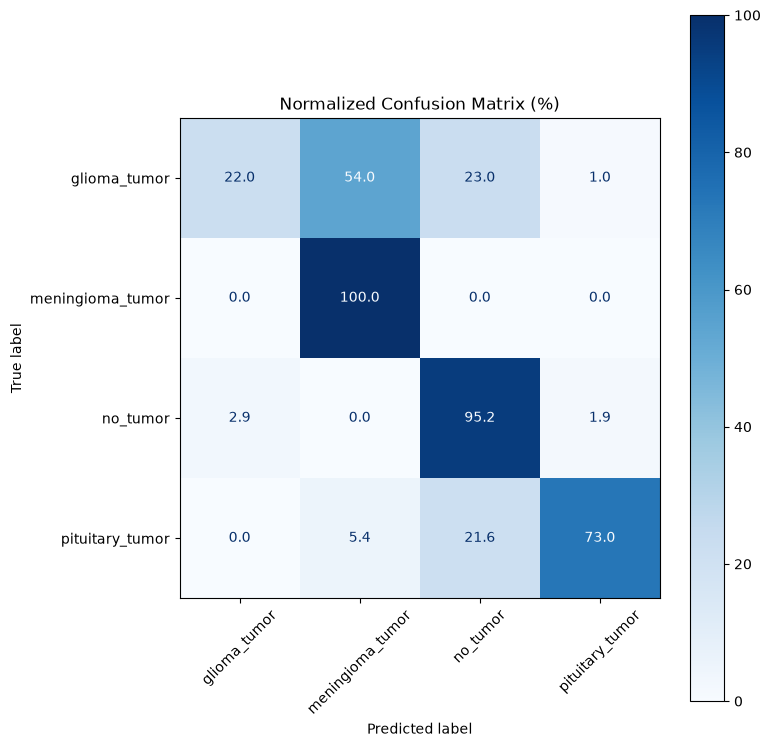

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)

# Convert each row to percentages
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent,
    display_labels=test_dataset.classes
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".1f",
    xticks_rotation=45
)

plt.title("Normalized Confusion Matrix (%)")
plt.tight_layout()
plt.show()

Replace your current train_transform with:

In [13]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Recreate the training dataset

In [16]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

In [39]:
from sklearn.model_selection import train_test_split

indices = list(range(len(train_dataset)))
labels = train_dataset.targets

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

Training samples: 2296
Validation samples: 574


In [40]:
from torch.utils.data import Subset, DataLoader

train_subset = Subset(
    train_dataset,
    train_indices
)

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

print("Train loader ready.")

Train loader ready.


In [41]:
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader

val_dataset_full = datasets.ImageFolder(
    train_dir,
    transform=test_transform
)

val_subset = Subset(
    val_dataset_full,
    val_indices
)

val_loader = DataLoader(
    val_subset,
    batch_size=32,
    shuffle=False
)

print("Validation samples:", len(val_subset))
print("Validation loader ready.")

Validation samples: 574
Validation loader ready.


In [42]:
import torch
import torch.nn as nn
from torchvision import models

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate ResNet18
model = models.resnet18(weights=None)

num_classes = 4

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

# Load your previous best model
model.load_state_dict(
    torch.load(
        "best_brain_mri_resnet18.pth",
        map_location=device
    )
)

# Class weights
class_counts = [826, 822, 395, 827]
total = sum(class_counts)

class_weights = torch.tensor(
    [
        total / (num_classes * count)
        for count in class_counts
    ],
    dtype=torch.float32
).to(device)

# Loss
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Model:", type(model).__name__)
print("Device:", device)
print("Model + loss + optimizer ready.")

Model: ResNet
Device: cpu
Model + loss + optimizer ready.


In [43]:
import copy
import torch

num_epochs = 5

best_val_accuracy = 0.0
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    # =========================
    # Training
    # =========================
    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_loss / train_total
    train_accuracy = 100 * train_correct / train_total

    # =========================
    # Validation
    # =========================
    model.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss_total / val_total
    val_accuracy = 100 * val_correct / val_total

    # =========================
    # Save best model
    # =========================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_state,
            "best_brain_mri_resnet18_augmented.pth"
        )

        print(">>> Best model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

print(
    f"\nBest Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

>>> Best model saved!
Epoch [1/5] Train Loss: 0.0359 Train Acc: 98.91% Val Loss: 0.0811 Val Acc: 97.91%
Epoch [2/5] Train Loss: 0.0256 Train Acc: 99.09% Val Loss: 0.1670 Val Acc: 95.12%
Epoch [3/5] Train Loss: 0.0319 Train Acc: 98.95% Val Loss: 0.1192 Val Acc: 95.82%
Epoch [4/5] Train Loss: 0.0243 Train Acc: 99.04% Val Loss: 0.0612 Val Acc: 97.04%
>>> Best model saved!
Epoch [5/5] Train Loss: 0.0069 Train Acc: 99.87% Val Loss: 0.0680 Val Acc: 98.08%

Best Validation Accuracy: 98.08%


load the new best model

In [44]:
model.load_state_dict(
    torch.load(
        "best_brain_mri_resnet18_augmented.pth",
        map_location=device
    )
)

model.eval()

print("Best augmented model loaded.")

Best augmented model loaded.


In [45]:
from sklearn.metrics import classification_report

all_predictions_aug = []
all_labels_aug = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions_aug.extend(
            predicted.cpu().numpy()
        )

        all_labels_aug.extend(
            labels.numpy()
        )

test_correct = sum(
    p == y
    for p, y in zip(
        all_predictions_aug,
        all_labels_aug
    )
)

test_accuracy_aug = (
    100 * test_correct / len(all_labels_aug)
)

print(
    f"Augmented Test Accuracy: "
    f"{test_accuracy_aug:.2f}%"
)

print(
    classification_report(
        all_labels_aug,
        all_predictions_aug,
        target_names=test_dataset.classes
    )
)

Augmented Test Accuracy: 76.14%
                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.24      0.39       100
meningioma_tumor       0.74      0.97      0.84       115
        no_tumor       0.66      1.00      0.80       105
 pituitary_tumor       1.00      0.80      0.89        74

        accuracy                           0.76       394
       macro avg       0.85      0.75      0.73       394
    weighted avg       0.83      0.76      0.72       394



In [46]:
from collections import Counter

error_pairs_aug = Counter(
    (
        test_dataset.classes[actual],
        test_dataset.classes[pred]
    )
    for actual, pred in zip(
        all_labels_aug,
        all_predictions_aug
    )
    if actual != pred
)

for (actual, predicted), count in error_pairs_aug.most_common():
    print(f"{actual} -> {predicted}: {count}")

glioma_tumor -> no_tumor: 40
glioma_tumor -> meningioma_tumor: 36
pituitary_tumor -> no_tumor: 11
pituitary_tumor -> meningioma_tumor: 4
meningioma_tumor -> no_tumor: 3


In [47]:
class_weights_glioma = torch.tensor(
    [1.5, 0.87, 1.82, 0.87],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_glioma
)

print("New class weights:", class_weights_glioma)

New class weights: tensor([1.5000, 0.8700, 1.8200, 0.8700])


In [48]:
model.load_state_dict(
    torch.load(
        "best_brain_mri_resnet18_augmented.pth",
        map_location=device
    )
)

print("Best augmented model loaded.")

Best augmented model loaded.


In [49]:
import copy
import torch

num_epochs = 5

best_val_accuracy = 0.0
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    # =========================
    # Training
    # =========================
    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_loss / train_total
    train_accuracy = 100 * train_correct / train_total

    # =========================
    # Validation
    # =========================
    model.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss_total / val_total
    val_accuracy = 100 * val_correct / val_total

    # =========================
    # Save best model
    # =========================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_state,
            "best_brain_mri_glioma_weighted.pth"
        )

        print(">>> Best model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

print(
    f"\nBest Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

>>> Best model saved!
Epoch [1/5] Train Loss: 0.0232 Train Acc: 99.26% Val Loss: 0.1592 Val Acc: 94.25%
>>> Best model saved!
Epoch [2/5] Train Loss: 0.0197 Train Acc: 99.48% Val Loss: 0.0703 Val Acc: 97.04%
Epoch [3/5] Train Loss: 0.0161 Train Acc: 99.39% Val Loss: 0.1416 Val Acc: 95.82%
Epoch [4/5] Train Loss: 0.0134 Train Acc: 99.65% Val Loss: 0.0869 Val Acc: 96.69%
Epoch [5/5] Train Loss: 0.0118 Train Acc: 99.74% Val Loss: 0.1630 Val Acc: 94.95%

Best Validation Accuracy: 97.04%


In [50]:
model.load_state_dict(
    torch.load(
        "best_brain_mri_glioma_weighted.pth",
        map_location=device
    )
)

model.eval()

print("Glioma-weighted model loaded.")

Glioma-weighted model loaded.


In [51]:
from sklearn.metrics import classification_report

all_predictions_weighted = []
all_labels_weighted = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions_weighted.extend(
            predicted.cpu().numpy()
        )

        all_labels_weighted.extend(
            labels.numpy()
        )

test_correct_weighted = sum(
    p == y
    for p, y in zip(
        all_predictions_weighted,
        all_labels_weighted
    )
)

test_accuracy_weighted = (
    100 * test_correct_weighted /
    len(all_labels_weighted)
)

print(
    f"Test Accuracy: "
    f"{test_accuracy_weighted:.2f}%"
)

print(
    classification_report(
        all_labels_weighted,
        all_predictions_weighted,
        target_names=test_dataset.classes
    )
)

Test Accuracy: 75.89%
                  precision    recall  f1-score   support

    glioma_tumor       0.85      0.33      0.47       100
meningioma_tumor       0.67      0.99      0.80       115
        no_tumor       0.75      0.94      0.84       105
 pituitary_tumor       1.00      0.72      0.83        74

        accuracy                           0.76       394
       macro avg       0.82      0.75      0.74       394
    weighted avg       0.80      0.76      0.73       394



In [52]:
best_brain_mri_resnet18.pth
best_brain_mri_resnet18_augmented.pth
best_brain_mri_glioma_weighted.pth

NameError: name 'best_brain_mri_resnet18' is not defined

In [53]:
import os

files = [
    "best_brain_mri_resnet18.pth",
    "best_brain_mri_resnet18_augmented.pth",
    "best_brain_mri_glioma_weighted.pth"
]

for file in files:
    print(file, "->", os.path.exists(file))

best_brain_mri_resnet18.pth -> True
best_brain_mri_resnet18_augmented.pth -> True
best_brain_mri_glioma_weighted.pth -> True


In [54]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "ResNet18 Baseline",
        "ResNet18 + Augmentation",
        "ResNet18 + Augmentation + Glioma Weight"
    ],
    "Validation Accuracy (%)": [
        97.39,
        98.08,
        97.04
    ],
    "Test Accuracy (%)": [
        73.86,
        76.14,
        75.89
    ],
    "Glioma Recall (%)": [
        22,
        24,
        33
    ]
})

comparison

,Model,Validation Accuracy (%),Test Accuracy (%),Glioma Recall (%)
0,ResNet18 Baseline,97.39,73.86,22
1,ResNet18 + Augmentation,98.08,76.14,24
2,ResNet18 + Augmentation + Glioma Weight,97.04,75.89,33


Using best Augmented model

In [55]:
import torch
import torch.nn as nn
from torchvision import models

# Create ResNet18
embedding_model = models.resnet18(weights=None)

# Same final layer as your trained model
embedding_model.fc = nn.Linear(
    embedding_model.fc.in_features,
    4
)

# Load best augmented model
embedding_model.load_state_dict(
    torch.load(
        "best_brain_mri_resnet18_augmented.pth",
        map_location=device
    )
)

embedding_model = embedding_model.to(device)

# Remove the final classifier
embedding_model.fc = nn.Identity()

embedding_model.eval()

print("Embedding model ready.")
print("Output dimension: 512")

Embedding model ready.
Output dimension: 512


Creating new dataset for our embedding as we are going to use Non-augmented tarnsform

In [56]:
embedding_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

embedding_dataset = datasets.ImageFolder(
    train_dir,
    transform=embedding_transform
)

embedding_loader = DataLoader(
    embedding_dataset,
    batch_size=32,
    shuffle=False
)

print("Images:", len(embedding_dataset))
print("Classes:", embedding_dataset.classes)

Images: 2870
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


Extract embedding

In [57]:
import numpy as np

all_embeddings = []
all_labels = []
all_paths = []

embedding_model.eval()

with torch.no_grad():

    for images, labels in embedding_loader:

        images = images.to(device)

        embeddings = embedding_model(images)

        all_embeddings.append(
            embeddings.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

# Combine all batches
all_embeddings = np.concatenate(
    all_embeddings,
    axis=0
)

all_labels = np.array(all_labels)

print("Embedding shape:", all_embeddings.shape)
print("Labels shape:", all_labels.shape)

Embedding shape: (2870, 512)
Labels shape: (2870,)


Save the embedding and metadata

In [58]:
import os
import numpy as np
import pandas as pd

# Create models directory
os.makedirs("../models", exist_ok=True)

# Save embeddings
np.save(
    "../models/brain_mri_embeddings.npy",
    all_embeddings
)

# Save labels
np.save(
    "../models/brain_mri_labels.npy",
    all_labels
)

# Save image paths and labels
image_paths = [
    path
    for path, _ in embedding_dataset.samples
]

metadata = pd.DataFrame({
    "path": image_paths,
    "label_id": all_labels,
    "label": [
        embedding_dataset.classes[label]
        for label in all_labels
    ]
})

metadata.to_csv(
    "../models/brain_mri_metadata.csv",
    index=False
)

print("Embeddings saved.")
print("Labels saved.")
print("Metadata saved.")
print("Embedding shape:", all_embeddings.shape)

Embeddings saved.
Labels saved.
Metadata saved.
Embedding shape: (2870, 512)


Create cosine similarity search

In [59]:
import torch
import torch.nn.functional as F
import numpy as np

def find_similar_images(
    query_image,
    embedding_model,
    stored_embeddings,
    metadata,
    top_k=5
):
    """
    Find the most similar MRI images to a query image.
    """

    embedding_model.eval()

    # Add batch dimension
    query_image = query_image.unsqueeze(0).to(device)

    # Create query embedding
    with torch.no_grad():
        query_embedding = embedding_model(query_image)

    # Normalize query vector
    query_embedding = F.normalize(
        query_embedding,
        p=2,
        dim=1
    )

    # Convert stored embeddings to tensor
    stored_embeddings_tensor = torch.tensor(
        stored_embeddings,
        dtype=torch.float32,
        device=device
    )

    # Normalize stored vectors
    stored_embeddings_tensor = F.normalize(
        stored_embeddings_tensor,
        p=2,
        dim=1
    )

    # Cosine similarity
    similarities = torch.mm(
        query_embedding,
        stored_embeddings_tensor.T
    ).squeeze(0)

    # Get top K
    top_scores, top_indices = torch.topk(
        similarities,
        k=top_k
    )

    results = metadata.iloc[
        top_indices.cpu().numpy()
    ].copy()

    results["similarity"] = (
        top_scores.cpu().numpy()
    )

    return results

Testing our Retrieval
By  picking one image and to serach Top5 Images similar to the Image

First load the embedding model

In [1]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

embedding_model = models.resnet18(weights=None)

embedding_model.fc = nn.Linear(
    embedding_model.fc.in_features,
    4
)

embedding_model.load_state_dict(
    torch.load(
        "best_brain_mri_resnet18_augmented.pth",
        map_location=device
    )
)

embedding_model.fc = nn.Identity()

embedding_model = embedding_model.to(device)
embedding_model.eval()

print("Embedding model loaded.")
print("Device:", device)

Embedding model loaded.
Device: cpu


Load stored Embeddings

In [2]:
import numpy as np
import pandas as pd

stored_embeddings = np.load(
    "../models/brain_mri_embeddings.npy"
)

metadata = pd.read_csv(
    "../models/brain_mri_metadata.csv"
)

print("Embeddings:", stored_embeddings.shape)
print("Metadata:", metadata.shape)

Embeddings: (2870, 512)
Metadata: (2870, 3)


Recreate the Dataset

In [3]:
from torchvision import datasets, transforms

embedding_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dir = "../Data/brain_tumor/Training"

embedding_dataset = datasets.ImageFolder(
    train_dir,
    transform=embedding_transform
)

print("Images:", len(embedding_dataset))
print("Classes:", embedding_dataset.classes)

Images: 2870
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [4]:
import torch
import torch.nn.functional as F
import numpy as np

def find_similar_images(
    query_image,
    embedding_model,
    stored_embeddings,
    metadata,
    top_k=5
):
    embedding_model.eval()

    # Add batch dimension: [512] → [1, 512]
    query_image = query_image.unsqueeze(0).to(device)

    # Generate query embedding
    with torch.no_grad():
        query_embedding = embedding_model(query_image)

    # Normalize query vector
    query_embedding = F.normalize(
        query_embedding,
        p=2,
        dim=1
    )

    # Convert stored embeddings to tensor
    stored_embeddings_tensor = torch.tensor(
        stored_embeddings,
        dtype=torch.float32,
        device=device
    )

    # Normalize stored vectors
    stored_embeddings_tensor = F.normalize(
        stored_embeddings_tensor,
        p=2,
        dim=1
    )

    # Cosine similarity
    similarities = torch.mm(
        query_embedding,
        stored_embeddings_tensor.T
    ).squeeze(0)

    # Get top-k most similar images
    top_scores, top_indices = torch.topk(
        similarities,
        k=top_k
    )

    # Retrieve metadata
    results = metadata.iloc[
        top_indices.cpu().numpy()
    ].copy()

    results["similarity"] = (
        top_scores.cpu().numpy()
    )

    return results

Selecta query Image

In [5]:
import random

query_index = random.randint(0, len(embedding_dataset) - 1)

query_image, query_label = embedding_dataset[query_index]

query_path = embedding_dataset.samples[query_index][0]

print("Query index:", query_index)
print("Actual class:", embedding_dataset.classes[query_label])
print("Query image:", query_path)

Query index: 135
Actual class: glioma_tumor
Query image: ../Data/brain_tumor/Training\glioma_tumor\gg (220).jpg


Retrieve The 5 most similar Images

In [6]:
results = find_similar_images(
    query_image=query_image,
    embedding_model=embedding_model,
    stored_embeddings=stored_embeddings,
    metadata=metadata,
    top_k=5
)

print(results)

                                                  path  label_id  \
135  ../Data/brain_tumor/Training\glioma_tumor\gg (...         0   
136  ../Data/brain_tumor/Training\glioma_tumor\gg (...         0   
760  ../Data/brain_tumor/Training\glioma_tumor\gg (...         0   
66   ../Data/brain_tumor/Training\glioma_tumor\gg (...         0   
819  ../Data/brain_tumor/Training\glioma_tumor\gg (...         0   

            label  similarity  
135  glioma_tumor    1.000000  
136  glioma_tumor    0.971131  
760  glioma_tumor    0.969830  
66   glioma_tumor    0.969361  
819  glioma_tumor    0.969153  


Now exclude the query

In [7]:
def find_similar_images(
    query_image,
    embedding_model,
    stored_embeddings,
    metadata,
    top_k=5,
    exclude_index=None
):
    embedding_model.eval()

    query_image = query_image.unsqueeze(0).to(device)

    with torch.no_grad():
        query_embedding = embedding_model(query_image)

    query_embedding = F.normalize(
        query_embedding,
        p=2,
        dim=1
    )

    stored_embeddings_tensor = torch.tensor(
        stored_embeddings,
        dtype=torch.float32,
        device=device
    )

    stored_embeddings_tensor = F.normalize(
        stored_embeddings_tensor,
        p=2,
        dim=1
    )

    similarities = torch.mm(
        query_embedding,
        stored_embeddings_tensor.T
    ).squeeze(0)

    # Remove the query image itself
    if exclude_index is not None:
        similarities[exclude_index] = -1

    top_scores, top_indices = torch.topk(
        similarities,
        k=top_k
    )

    results = metadata.iloc[
        top_indices.cpu().numpy()
    ].copy()

    results["similarity"] = (
        top_scores.cpu().numpy()
    )

    return results

In [8]:
results = find_similar_images(
    query_image=query_image,
    embedding_model=embedding_model,
    stored_embeddings=stored_embeddings,
    metadata=metadata,
    top_k=5,
    exclude_index=query_index
)

print(results)

                                                  path  label_id  \
136  ../Data/brain_tumor/Training\glioma_tumor\gg (...         0   
760  ../Data/brain_tumor/Training\glioma_tumor\gg (...         0   
66   ../Data/brain_tumor/Training\glioma_tumor\gg (...         0   
819  ../Data/brain_tumor/Training\glioma_tumor\gg (...         0   
769  ../Data/brain_tumor/Training\glioma_tumor\gg (...         0   

            label  similarity  
136  glioma_tumor    0.971131  
760  glioma_tumor    0.969830  
66   glioma_tumor    0.969361  
819  glioma_tumor    0.969153  
769  glioma_tumor    0.969020  


Display query and retrieved images

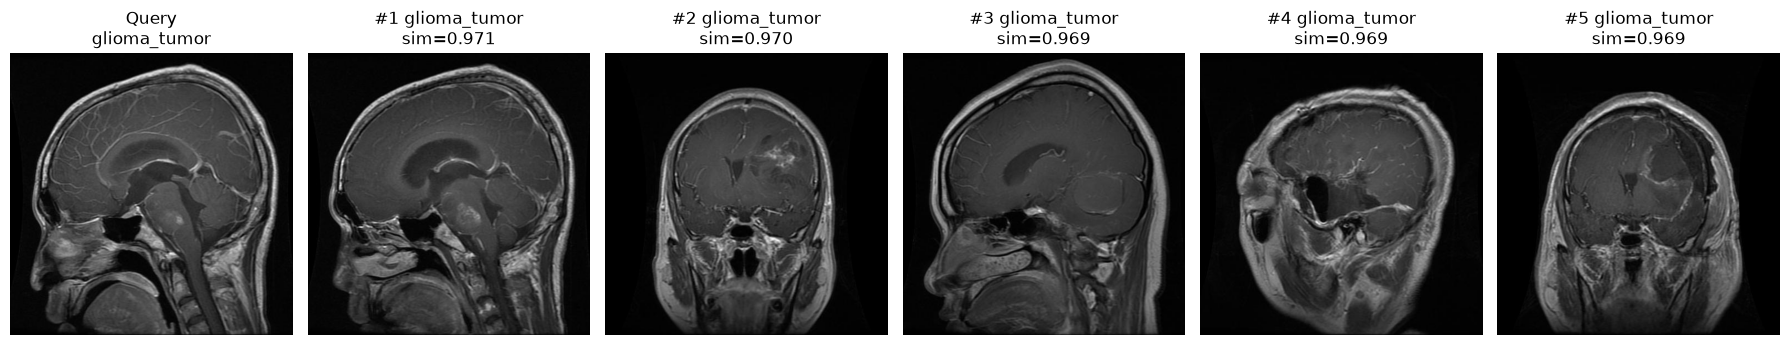

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 6, figsize=(18, 4))

# Query image
axes[0].imshow(Image.open(query_path))
axes[0].set_title(
    f"Query\n{embedding_dataset.classes[query_label]}"
)
axes[0].axis("off")

# Retrieved images
for i, (_, row) in enumerate(results.iterrows(), start=1):
    image = Image.open(row["path"])

    axes[i].imshow(image)
    axes[i].set_title(
        f"#{i} {row['label']}\n"
        f"sim={row['similarity']:.3f}"
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Testing Retrieval across all classes

In [10]:
import random
import pandas as pd

evaluation_results = []

for class_id, class_name in enumerate(embedding_dataset.classes):

    # Get all indices belonging to this class
    class_indices = [
        i for i, (_, label) in enumerate(embedding_dataset.samples)
        if label == class_id
    ]

    # Select one random query
    query_index = random.choice(class_indices)

    query_image, query_label = embedding_dataset[query_index]

    # Retrieve similar images
    results = find_similar_images(
        query_image=query_image,
        embedding_model=embedding_model,
        stored_embeddings=stored_embeddings,
        metadata=metadata,
        top_k=5,
        exclude_index=query_index
    )

    retrieved_labels = results["label"].tolist()

    correct = sum(
        label == class_name
        for label in retrieved_labels
    )

    precision_at_5 = correct / 5

    evaluation_results.append({
        "query_class": class_name,
        "query_index": query_index,
        "correct_retrievals": correct,
        "precision@5": precision_at_5,
        "retrieved_labels": retrieved_labels
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,query_class,query_index,correct_retrievals,precision@5,retrieved_labels
0,glioma_tumor,518,5,1.0,"[glioma_tumor, glioma_tumor, glioma_tumor, gli..."
1,meningioma_tumor,859,5,1.0,"[meningioma_tumor, meningioma_tumor, meningiom..."
2,no_tumor,1837,5,1.0,"[no_tumor, no_tumor, no_tumor, no_tumor, no_tu..."
3,pituitary_tumor,2817,5,1.0,"[pituitary_tumor, pituitary_tumor, pituitary_t..."


Test Many Queries

In [11]:
import random
import pandas as pd

retrieval_evaluation = []

for class_id, class_name in enumerate(embedding_dataset.classes):

    class_indices = [
        i for i, (_, label) in enumerate(embedding_dataset.samples)
        if label == class_id
    ]

    # Test 20 random queries from this class
    query_indices = random.sample(
        class_indices,
        min(20, len(class_indices))
    )

    for query_index in query_indices:

        query_image, query_label = embedding_dataset[query_index]

        results = find_similar_images(
            query_image=query_image,
            embedding_model=embedding_model,
            stored_embeddings=stored_embeddings,
            metadata=metadata,
            top_k=5,
            exclude_index=query_index
        )

        retrieved_labels = results["label"].tolist()

        correct = sum(
            label == class_name
            for label in retrieved_labels
        )

        precision_at_5 = correct / 5

        retrieval_evaluation.append({
            "query_class": class_name,
            "query_index": query_index,
            "correct_retrievals": correct,
            "precision_at_5": precision_at_5
        })

retrieval_df = pd.DataFrame(retrieval_evaluation)

print("Total queries:", len(retrieval_df))
print("\nOverall Precision@5:")
print(retrieval_df["precision_at_5"].mean())

print("\nPrecision@5 by class:")
print(
    retrieval_df
    .groupby("query_class")["precision_at_5"]
    .mean()
)

Total queries: 80

Overall Precision@5:
0.9949999999999999

Precision@5 by class:
query_class
glioma_tumor        1.00
meningioma_tumor    0.98
no_tumor            1.00
pituitary_tumor     1.00
Name: precision_at_5, dtype: float64


Test retrieval on the separate Testing dataset

Create test query Dataset

In [12]:
from torchvision import datasets, transforms

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder(
    "../Data/brain_tumor/Testing",
    transform=test_transform
)

print("Test images:", len(test_dataset))
print("Classes:", test_dataset.classes)

Test images: 394
Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


Evaluate test-set retrieval

In [13]:
retrieval_test_results = []

for query_index in range(len(test_dataset)):

    # Get test image and its true class
    query_image, query_label = test_dataset[query_index]

    query_class = test_dataset.classes[query_label]

    # Retrieve top 5 similar images
    results = find_similar_images(
        query_image=query_image,
        embedding_model=embedding_model,
        stored_embeddings=stored_embeddings,
        metadata=metadata,
        top_k=5
    )

    retrieved_labels = results["label"].tolist()

    # Count how many retrieved images have the correct class
    correct = sum(
        label == query_class
        for label in retrieved_labels
    )

    precision_at_5 = correct / 5

    retrieval_test_results.append({
        "query_index": query_index,
        "query_class": query_class,
        "correct_retrievals": correct,
        "precision_at_5": precision_at_5
    })

retrieval_test_df = pd.DataFrame(
    retrieval_test_results
)

print("Total test queries:", len(retrieval_test_df))

print("\nOverall Precision@5:")
print(
    retrieval_test_df["precision_at_5"].mean()
)

print("\nPrecision@5 by class:")
print(
    retrieval_test_df
    .groupby("query_class")["precision_at_5"]
    .mean()
)

Total test queries: 394

Overall Precision@5:
0.7477157360406091

Precision@5 by class:
query_class
glioma_tumor        0.204000
meningioma_tumor    0.991304
no_tumor            0.988571
pituitary_tumor     0.762162
Name: precision_at_5, dtype: float64


In [14]:
import random

# Find all glioma images in the test set
glioma_indices = [
    i
    for i, (_, label) in enumerate(test_dataset.samples)
    if test_dataset.classes[label] == "glioma_tumor"
]

# Select 5 random glioma test images
selected_indices = random.sample(glioma_indices, 5)

for query_index in selected_indices:

    query_image, query_label = test_dataset[query_index]

    print("=" * 70)
    print("Query index:", query_index)
    print("True class:", test_dataset.classes[query_label])
    print()

    results = find_similar_images(
        query_image=query_image,
        embedding_model=embedding_model,
        stored_embeddings=stored_embeddings,
        metadata=metadata,
        top_k=5
    )

    print(
        results[
            ["label", "similarity"]
        ].to_string(index=False)
    )

Query index: 93
True class: glioma_tumor

           label  similarity
meningioma_tumor    0.901958
meningioma_tumor    0.894419
meningioma_tumor    0.892231
meningioma_tumor    0.872621
meningioma_tumor    0.850515
Query index: 75
True class: glioma_tumor

   label  similarity
no_tumor    0.921241
no_tumor    0.921178
no_tumor    0.909480
no_tumor    0.902022
no_tumor    0.901943
Query index: 69
True class: glioma_tumor

       label  similarity
glioma_tumor    1.000000
glioma_tumor    0.984349
glioma_tumor    0.982207
glioma_tumor    0.981395
glioma_tumor    0.979667
Query index: 4
True class: glioma_tumor

   label  similarity
no_tumor    0.920493
no_tumor    0.920493
no_tumor    0.920493
no_tumor    0.920347
no_tumor    0.919689
Query index: 68
True class: glioma_tumor

       label  similarity
glioma_tumor    1.000000
glioma_tumor    0.984349
glioma_tumor    0.982207
glioma_tumor    0.981395
glioma_tumor    0.979667


In [15]:
from collections import Counter
import pandas as pd

retrieval_confusion = []

for query_index in range(len(test_dataset)):

    query_image, query_label = test_dataset[query_index]

    true_class = test_dataset.classes[query_label]

    results = find_similar_images(
        query_image=query_image,
        embedding_model=embedding_model,
        stored_embeddings=stored_embeddings,
        metadata=metadata,
        top_k=5
    )

    retrieved_labels = results["label"].tolist()

    # Most common class among top-5
    majority_class = Counter(
        retrieved_labels
    ).most_common(1)[0][0]

    retrieval_confusion.append({
        "true_class": true_class,
        "retrieved_majority_class": majority_class
    })

retrieval_confusion_df = pd.DataFrame(
    retrieval_confusion
)

confusion_table = pd.crosstab(
    retrieval_confusion_df["true_class"],
    retrieval_confusion_df["retrieved_majority_class"]
)

print(confusion_table)

retrieved_majority_class  glioma_tumor  meningioma_tumor  no_tumor  \
true_class                                                           
glioma_tumor                        19                45        36   
meningioma_tumor                     0               114         1   
no_tumor                             0                 0       105   
pituitary_tumor                      0                 4        13   

retrieved_majority_class  pituitary_tumor  
true_class                                 
glioma_tumor                            0  
meningioma_tumor                        0  
no_tumor                                0  
pituitary_tumor                        57  


PCA visualization

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce 512 dimensions → 2 dimensions
pca = PCA(n_components=2, random_state=42)

embeddings_2d = pca.fit_transform(
    stored_embeddings
)

print("Original shape:", stored_embeddings.shape)
print("PCA shape:", embeddings_2d.shape)
print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

Original shape: (2870, 512)
PCA shape: (2870, 2)
Explained variance: [0.34217435 0.26416242]


In [17]:
plt.figure(figsize=(10, 7))

for class_id, class_name in enumerate(
    embedding_dataset.classes
):

    mask = all_labels == class_id

    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=class_name,
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Brain MRI Embedding Space — PCA")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'all_labels' is not defined

<Figure size 1000x700 with 0 Axes>

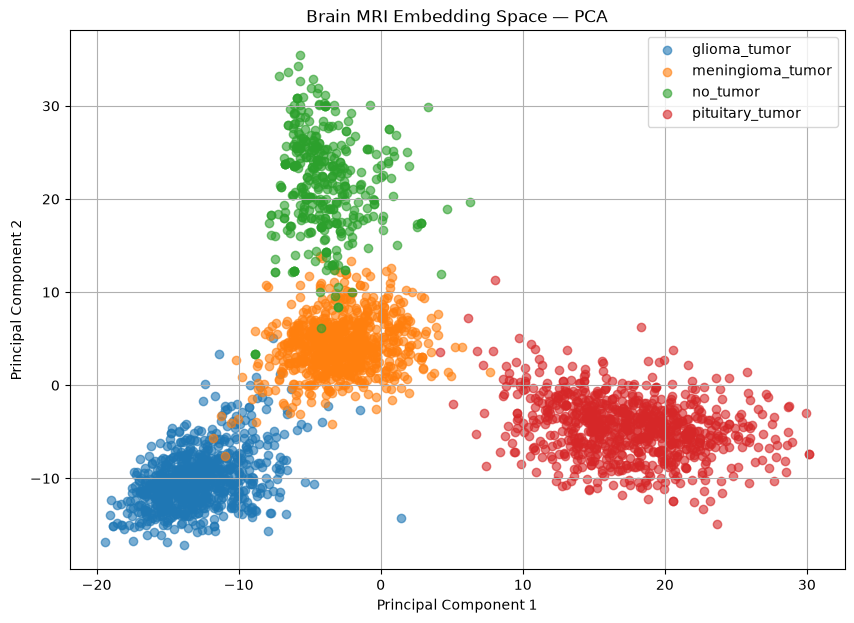

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Get labels from saved metadata
all_labels = metadata["label_id"].to_numpy()

plt.figure(figsize=(10, 7))

for class_id, class_name in enumerate(
    embedding_dataset.classes
):

    mask = all_labels == class_id

    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=class_name,
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Brain MRI Embedding Space — PCA")
plt.legend()
plt.grid(True)
plt.show()

Generate test embeddings

In [19]:
test_embeddings = []

test_embedding_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

embedding_model.eval()

with torch.no_grad():
    for images, labels in test_embedding_loader:
        images = images.to(device)

        embeddings = embedding_model(images)

        test_embeddings.append(
            embeddings.cpu().numpy()
        )

test_embeddings = np.concatenate(
    test_embeddings,
    axis=0
)

print("Test embeddings:", test_embeddings.shape)

Test embeddings: (394, 512)


Transform test embeddings with the existing PCA

In [20]:
test_embeddings_2d = pca.transform(
    test_embeddings
)

print(
    "Test PCA shape:",
    test_embeddings_2d.shape
)

Test PCA shape: (394, 2)


Plot training and Test Embedding

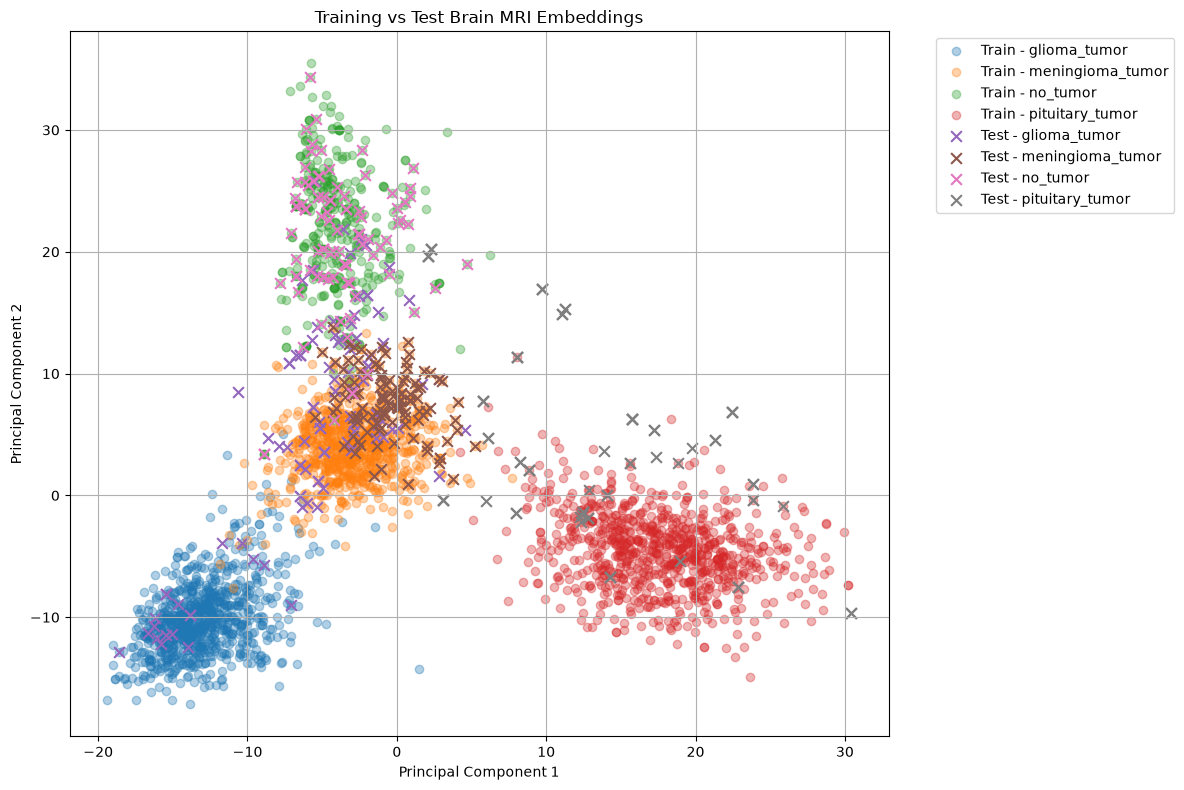

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Training embeddings
for class_id, class_name in enumerate(
    embedding_dataset.classes
):
    mask = all_labels == class_id

    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=f"Train - {class_name}",
        alpha=0.35
    )

# Test embeddings
test_labels = np.array(test_dataset.targets)

for class_id, class_name in enumerate(
    test_dataset.classes
):
    mask = test_labels == class_id

    plt.scatter(
        test_embeddings_2d[mask, 0],
        test_embeddings_2d[mask, 1],
        marker="x",
        s=60,
        label=f"Test - {class_name}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Training vs Test Brain MRI Embeddings")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

First, create the pretrained embedding model

In [22]:
from torchvision import models
import torch
import torch.nn as nn

pretrained_embedding_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Remove the classification layer
pretrained_embedding_model.fc = nn.Identity()

pretrained_embedding_model = (
    pretrained_embedding_model.to(device)
)

pretrained_embedding_model.eval()

print("Pretrained embedding model ready.")

Pretrained embedding model ready.


Generate pretrained embeddings

In [23]:
pretrained_embeddings = []

embedding_loader = torch.utils.data.DataLoader(
    embedding_dataset,
    batch_size=32,
    shuffle=False
)

pretrained_embedding_model.eval()

with torch.no_grad():
    for images, labels in embedding_loader:

        images = images.to(device)

        embeddings = pretrained_embedding_model(images)

        pretrained_embeddings.append(
            embeddings.cpu().numpy()
        )

pretrained_embeddings = np.concatenate(
    pretrained_embeddings,
    axis=0
)

print(
    "Pretrained embeddings:",
    pretrained_embeddings.shape
)

Pretrained embeddings: (2870, 512)


Generate test embeddings

In [24]:
pretrained_test_embeddings = []

test_embedding_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

pretrained_embedding_model.eval()

with torch.no_grad():
    for images, labels in test_embedding_loader:

        images = images.to(device)

        embeddings = pretrained_embedding_model(images)

        pretrained_test_embeddings.append(
            embeddings.cpu().numpy()
        )

pretrained_test_embeddings = np.concatenate(
    pretrained_test_embeddings,
    axis=0
)

print(
    "Pretrained test embeddings:",
    pretrained_test_embeddings.shape
)

Pretrained test embeddings: (394, 512)


Evaluate pretrained embeddings

In [25]:
pretrained_retrieval_results = []

# Normalize all training embeddings once
train_embeddings_tensor = torch.tensor(
    pretrained_embeddings,
    dtype=torch.float32,
    device=device
)

train_embeddings_tensor = F.normalize(
    train_embeddings_tensor,
    p=2,
    dim=1
)

# Normalize all test embeddings
test_embeddings_tensor = torch.tensor(
    pretrained_test_embeddings,
    dtype=torch.float32,
    device=device
)

test_embeddings_tensor = F.normalize(
    test_embeddings_tensor,
    p=2,
    dim=1
)

# Calculate similarities for ALL test queries at once
similarities = torch.mm(
    test_embeddings_tensor,
    train_embeddings_tensor.T
)

# Top 5 for every test image
top_scores, top_indices = torch.topk(
    similarities,
    k=5,
    dim=1
)

for query_index in range(len(test_dataset)):

    true_label = test_dataset.classes[
        test_dataset.targets[query_index]
    ]

    retrieved_indices = (
        top_indices[query_index]
        .cpu()
        .numpy()
    )

    retrieved_labels = metadata.iloc[
        retrieved_indices
    ]["label"].tolist()

    correct = sum(
        label == true_label
        for label in retrieved_labels
    )

    pretrained_retrieval_results.append({
        "query_index": query_index,
        "query_class": true_label,
        "correct_retrievals": correct,
        "precision_at_5": correct / 5
    })

pretrained_retrieval_df = pd.DataFrame(
    pretrained_retrieval_results
)

print(
    "Overall Precision@5:",
    pretrained_retrieval_df["precision_at_5"].mean()
)

print("\nPrecision@5 by class:")

print(
    pretrained_retrieval_df
    .groupby("query_class")["precision_at_5"]
    .mean()
)

Overall Precision@5: 0.6076142131979695

Precision@5 by class:
query_class
glioma_tumor        0.318000
meningioma_tumor    0.600000
no_tumor            0.784762
pituitary_tumor     0.759459
Name: precision_at_5, dtype: float64


Calculate Recall@5 for your fine-tuned embeddings

In [26]:
recall_results = []

for query_index in range(len(test_dataset)):

    query_image, query_label = test_dataset[query_index]

    true_class = test_dataset.classes[query_label]

    results = find_similar_images(
        query_image=query_image,
        embedding_model=embedding_model,
        stored_embeddings=stored_embeddings,
        metadata=metadata,
        top_k=5
    )

    retrieved_labels = results["label"].tolist()

    # Recall@5:
    # Did at least one correct-class image appear?
    hit = true_class in retrieved_labels

    recall_results.append({
        "query_index": query_index,
        "query_class": true_class,
        "recall_at_5": int(hit)
    })

recall_df = pd.DataFrame(recall_results)

print("Overall Recall@5:")
print(recall_df["recall_at_5"].mean())

print("\nRecall@5 by class:")
print(
    recall_df
    .groupby("query_class")["recall_at_5"]
    .mean()
)

Overall Recall@5:
0.7893401015228426

Recall@5 by class:
query_class
glioma_tumor        0.240000
meningioma_tumor    1.000000
no_tumor            1.000000
pituitary_tumor     0.905405
Name: recall_at_5, dtype: float64


In [27]:
import random
import torch
from torch.utils.data import Dataset
from torchvision import datasets, transforms

class ContrastiveBrainDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.dataset = datasets.ImageFolder(
            root_dir,
            transform=transform
        )

        self.labels = self.dataset.targets

        # Store indices for each class
        self.class_to_indices = {}

        for label in range(len(self.dataset.classes)):
            self.class_to_indices[label] = [
                i
                for i, target in enumerate(self.labels)
                if target == label
            ]

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):

        image1, label1 = self.dataset[index]

        # 50% positive pair, 50% negative pair
        same_class = random.random() < 0.5

        if same_class:

            # Choose another image from same class
            index2 = random.choice(
                self.class_to_indices[label1]
            )

            pair_label = 1.0

        else:

            # Choose a different class
            different_classes = [
                c
                for c in self.class_to_indices
                if c != label1
            ]

            label2 = random.choice(
                different_classes
            )

            index2 = random.choice(
                self.class_to_indices[label2]
            )

            pair_label = 0.0

        image2, _ = self.dataset[index2]

        return (
            image1,
            image2,
            torch.tensor(pair_label, dtype=torch.float32)
        )

In [28]:
contrastive_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

contrastive_dataset = ContrastiveBrainDataset(
    "../Data/brain_tumor/Training",
    transform=contrastive_transform
)

print("Contrastive dataset size:", len(contrastive_dataset))

Contrastive dataset size: 2870


Create the DataLoader

In [29]:
from torch.utils.data import DataLoader

contrastive_loader = DataLoader(
    contrastive_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

print("Batches per epoch:", len(contrastive_loader))

Batches per epoch: 90


In [30]:
images1, images2, pair_labels = next(
    iter(contrastive_loader)
)

print("Image 1 shape:", images1.shape)
print("Image 2 shape:", images2.shape)
print("Pair labels:", pair_labels[:10])

Image 1 shape: torch.Size([32, 3, 224, 224])
Image 2 shape: torch.Size([32, 3, 224, 224])
Pair labels: tensor([1., 0., 0., 0., 0., 1., 1., 1., 1., 1.])


In [31]:
import torch
import torch.nn as nn
from torchvision import models


class ContrastiveResNet18(nn.Module):

    def __init__(self, embedding_dim=128):

        super().__init__()

        # Load pretrained ResNet18
        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        # Original ResNet18 feature size = 512
        num_features = self.backbone.fc.in_features

        # Remove classification layer
        self.backbone.fc = nn.Identity()

        # Create embedding projection
        self.embedding = nn.Linear(
            num_features,
            embedding_dim
        )

    def forward(self, x):

        features = self.backbone(x)

        embeddings = self.embedding(features)

        # Normalize embeddings
        embeddings = nn.functional.normalize(
            embeddings,
            p=2,
            dim=1
        )

        return embeddings

In [32]:
criterion = nn.CosineEmbeddingLoss(
    margin=0.2
)

print("Contrastive loss ready.")

Contrastive loss ready.


In [33]:
optimizer = torch.optim.Adam(
    contrastive_model.parameters(),
    lr=1e-4
)

print("Optimizer ready.")

NameError: name 'contrastive_model' is not defined